# AIG4B — Clase 12
## Práctica: ECG, EEG y PPG — lo esencial

Tarea acompañante de la **Clase 12** (señales 1D biomédicas). Los datos vienen hechos; los **modelos los implementan ustedes** siguiendo las especificaciones del PDF de la clase.

Ejercicios:

- **1.1** — usar `neurokit2` para estimar bpm en ECG sintético.
- **1.2** — implementar la **toy CNN** de slide 21 y entrenarla para clasificar arritmias.
- **2.1** — implementar **EEGNet** siguiendo slide 29 para clasificar carga cognitiva.
- **3.1** — implementar un **mini-Transformer 1D** y verificar que resuelve la tarea de contexto largo donde una CNN falla.

Autores: Paulo Veiga y Marco Sanchez Sorondo · Mayo 2026

## Setup

La primera celda instala lo que falte (necesario en Colab).

In [ ]:
import importlib, subprocess, sys
for pkg in ['wfdb', 'neurokit2']:
    try: importlib.import_module(pkg)
    except ImportError:
        print(f'instalando {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('listo')

instalando wfdb...
instalando neurokit2...
listo


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sps
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import wfdb, neurokit2 as nk

np.random.seed(0); torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
plt.rcParams['figure.figsize'] = (11, 3.5)
plt.rcParams['axes.grid'] = True
print(f'torch v{torch.__version__}  device={device}')

torch v2.11.0+cpu  device=cpu


## 1. ECG

**Idea central (slides 11, 14, 21):** un ECG es una secuencia de números + `fs`. La detección clásica de R-peaks es Pan-Tompkins; la versión AI usa CNNs. Para arritmias, una CNN simple ya supera lo que se podría hacer a mano con reglas R-R.

Cargamos un registro real de **MIT-BIH** (PhysioNet) y vemos cómo `neurokit2` lo procesa.

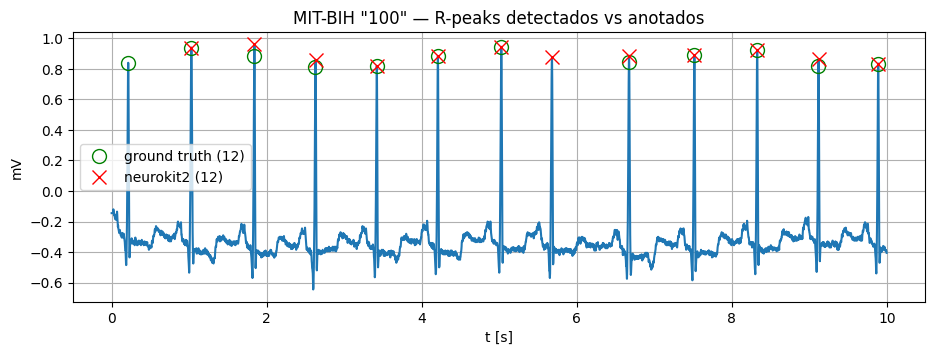

In [ ]:
FS_ECG = 360
record = wfdb.rdrecord('100', pn_dir='mitdb', sampto=10*FS_ECG)
ecg_raw = record.p_signal[:, 0]
t_ecg = np.arange(len(ecg_raw)) / FS_ECG

ann = wfdb.rdann('100', 'atr', pn_dir='mitdb', sampto=10*FS_ECG)
r_gt = np.array([s for s, sym in zip(ann.sample, ann.symbol) if sym == 'N'])

_, info = nk.ecg_peaks(ecg_raw, sampling_rate=FS_ECG)
r_nk = info['ECG_R_Peaks']

plt.plot(t_ecg, ecg_raw)
plt.plot(t_ecg[r_gt], ecg_raw[r_gt], 'go', ms=10, mfc='none', label=f'ground truth ({len(r_gt)})')
plt.plot(t_ecg[r_nk], ecg_raw[r_nk], 'rx', ms=10, label=f'neurokit2 ({len(r_nk)})')
plt.xlabel('t [s]'); plt.ylabel('mV'); plt.legend()
plt.title('MIT-BIH "100" — R-peaks detectados vs anotados')
plt.show()

### Helper · generador de ECG sintético

Función provista para los ejercicios. **No es parte del ejercicio**, solo úsenla.

In [ ]:
def synthetic_ecg(duration_s, fs, hr_bpm):
    """ECG sintético: suma de gaussianas P-Q-R-S-T repetidas a hr_bpm."""
    t = np.arange(0, duration_s, 1/fs); rr = 60.0/hr_bpm
    ecg = np.zeros_like(t)
    waves = [(0.00,0.025,0.15),(0.15,0.010,-0.10),(0.17,0.008,1.20),(0.19,0.010,-0.25),(0.35,0.04,0.35)]
    for k in range(int(duration_s/rr)+1):
        t0 = k * rr
        for off, sigma, amp in waves:
            ecg += amp * np.exp(-((t-t0-off)**2)/(2*sigma**2))
    return t, ecg

### Ejercicio 1.1 — estimar bpm con `neurokit2`

1. Generá un ECG sintético de 30 s con frecuencia cardíaca aleatoria entre 50 y 110 bpm (sin imprimir cuál).
2. Usá `nk.ecg_peaks` para detectar los R-peaks.
3. Estimá la frecuencia cardíaca a partir de los intervalos R-R y comparala con el valor real.

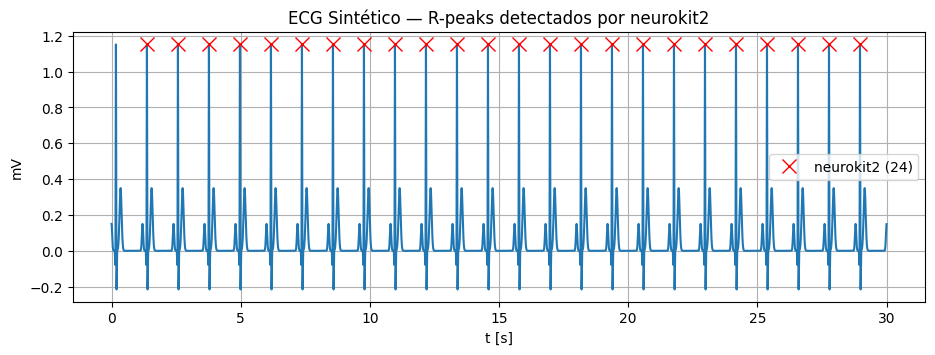

In [ ]:
t_synthetic, se_synthetic = synthetic_ecg(30, FS_ECG, np.random.randint(50, 110))
_, info = nk.ecg_peaks(se_synthetic, sampling_rate=FS_ECG)
r_nk = info['ECG_R_Peaks']

plt.plot(t_synthetic, se_synthetic)
plt.plot(t_synthetic[r_nk], se_synthetic[r_nk], 'go', ms=10, mfc='none', label=f'ground truth ({len(r_gt)})')
plt.plot(t_synthetic[r_nk], se_synthetic[r_nk], 'rx', ms=10, label=f'neurokit2 ({len(r_nk)})')
plt.xlabel('t [s]'); plt.ylabel('mV'); plt.legend()
plt.title('ECG Sintético — R-peaks detectados por neurokit2')
plt.show()

### Dataset de arritmias (provisto)

Tres clases (slide 13): **normal** (RR regular), **AFIB** (RR aleatorio + morfología sucia), **bigeminismo** (RR alternante corto-largo). El dataset y el split train/val vienen hechos; ustedes se ocupan del modelo.

Train: (720, 500)  Val: (180, 500)  Clases: ['normal', 'AFIB', 'bigeminismo']


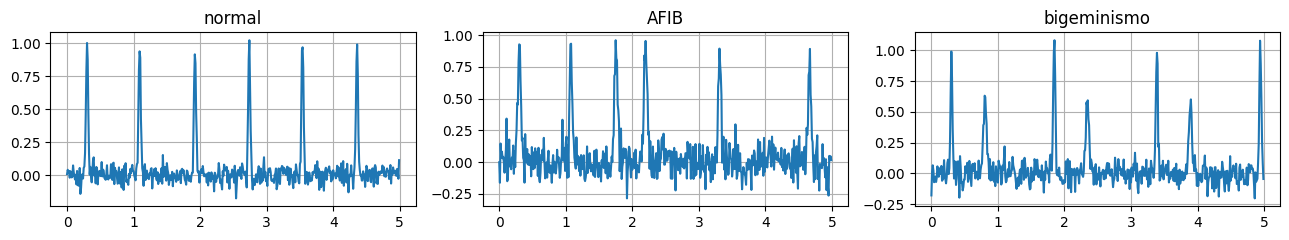

In [ ]:
FS = 100; WIN = 500  # 5 s a 100 Hz

def make_rr_window(label, rng):
    t = np.arange(WIN) / FS
    sig = np.zeros(WIN, dtype=np.float32)
    if label == 0:
        hr = rng.uniform(60, 80)
        rrs = np.full(15, 60/hr) + rng.normal(0, 0.02, 15)
        amps, widths, noise = np.full(15, 1.0), np.full(15, 0.015), 0.05
    elif label == 1:
        rrs = rng.uniform(0.4, 1.4, 15)
        amps = np.full(15, 0.9) + rng.normal(0, 0.10, 15)
        widths = rng.uniform(0.018, 0.025, 15); noise = 0.10
    else:
        s = rng.uniform(0.45, 0.55); l = rng.uniform(1.05, 1.20)
        rrs = np.array([s, l] * 8)[:15] + rng.normal(0, 0.02, 15)
        amps = np.array([1.0, 0.6] * 8)[:15]
        widths = np.array([0.015, 0.025] * 8)[:15]; noise = 0.07
    t_pos = 0.3
    for rr, amp, w in zip(rrs, amps, widths):
        if t_pos >= WIN / FS: break
        sig += amp * np.exp(-((t - t_pos) ** 2) / (2 * w ** 2))
        t_pos += rr
    return sig + noise * rng.standard_normal(WIN).astype(np.float32)

rng = np.random.default_rng(0); n_per = 300
labels_arr = ['normal', 'AFIB', 'bigeminismo']
X = np.stack([make_rr_window(c, rng) for c in [0]*n_per + [1]*n_per + [2]*n_per])
y = np.array([0]*n_per + [1]*n_per + [2]*n_per, dtype=np.int64)
idx = rng.permutation(len(X)); X, y = X[idx], y[idx]
split = int(0.8*len(X))
X_tr, X_va, y_tr, y_va = X[:split], X[split:], y[:split], y[split:]
print(f'Train: {X_tr.shape}  Val: {X_va.shape}  Clases: {labels_arr}')

fig, axes = plt.subplots(1, 3, figsize=(13, 2.5))
for ax, c in zip(axes, [0, 1, 2]):
    ax.plot(np.arange(WIN)/FS, X[y == c][0])
    ax.set_title(labels_arr[c])
plt.tight_layout(); plt.show()

### Ejercicio 1.2 — implementar y entrenar la toy CNN (slide 21)

Implementá **exactamente** la arquitectura de la slide 21 y entrenala sobre el dataset de arritmias.

**Arquitectura:**
```
Conv1D(in=1, out=16, kernel_size=5)  →  ReLU  →  MaxPool1D(kernel=2)
Conv1D(in=16, out=32, kernel_size=5) →  ReLU
GlobalAvgPool1D  →  Flatten  →  Linear(32, 3)
```

**Entrenamiento:** 15 epochs, optimizer Adam (lr=1e-3), loss `CrossEntropyLoss`, batch size 32.

**Reportar:**
- `val_acc` final
- matriz de confusión 3×3
- **sensibilidad** (recall) y **especificidad** por clase (las dos métricas clínicas clave)

*Pista para GlobalAvgPool1D:* en PyTorch se logra con `nn.AdaptiveAvgPool1d(1)` seguido de `nn.Flatten()`.

In [ ]:
# Tu código acá
class ToyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=5),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(32, 3)
        )
    def forward(self, x):
        return self.net(x)

X_tr_t = torch.from_numpy(X_tr).unsqueeze(1)  # [N, 1, 500]
X_va_t = torch.from_numpy(X_va).unsqueeze(1)
y_tr_t = torch.from_numpy(y_tr)
y_va_t = torch.from_numpy(y_va)

loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

model = ToyCNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

for epoch in range(15):
    model.train()
    for xb, yb in loader:
        loss = crit(model(xb.to(device)), yb.to(device))
        opt.zero_grad(); loss.backward(); opt.step()

model.eval()
with torch.no_grad():
    pred = model(X_va_t.to(device)).argmax(1).cpu().numpy()

val_acc = (pred == y_va).mean()
print(f'val_acc = {val_acc:.3f}')

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_va, pred)
print('Matriz de confusión:')
print(cm)

for i, clase in enumerate(labels_arr):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    print(f'{clase}: sensibilidad={sens:.3f}, especificidad={spec:.3f}')

val_acc = 0.972
Matriz de confusión:
[[51  0  0]
 [ 0 66  0]
 [ 5  0 58]]
normal: sensibilidad=1.000, especificidad=0.961
AFIB: sensibilidad=1.000, especificidad=1.000
bigeminismo: sensibilidad=0.921, especificidad=1.000


### Preguntas conceptuales — toy CNN (Ej 1.2)

Justificá brevemente cada decisión de la arquitectura y del entrenamiento. Una o dos oraciones por pregunta.

1. ¿Por qué usamos `Conv1D` en vez de `Linear` para procesar la señal?
2. `kernel_size=5` a `fs=100 Hz`: ¿cuántos milisegundos cubre el kernel? ¿Por qué ese tamaño tiene sentido para un ECG?
3. ¿Para qué sirve `MaxPool1d(2)`?
4. ¿Por qué la segunda Conv1D pasa de 16 a 32 filtros (el número crece al profundizar)?
5. ¿Qué hace `AdaptiveAvgPool1d(1)`? ¿Qué se gana y qué se pierde al colapsar toda la dimensión temporal?
6. ¿Por qué la última capa `Linear` tiene **3** outputs y no hay activación softmax después?
7. ¿Por qué `CrossEntropyLoss` es la loss apropiada y por qué usamos `Adam` y no `SGD`?

1. Conv1D usa el mismo filtro deslizándose por toda la señal, entonces detecta un patrón (como un pico R) en cualquier posición. Con Linear tendría que aprender cada posición por separado.

2. 5 samples × (1/100 Hz) = 50 ms. Tiene sentido porque el complejo QRS dura unos 60-100 ms, entonces el kernel puede "verlo" casi completo.

3. Reduce la señal a la mitad descartando info redundante, hace el modelo más rápido y ayuda a que no se sobreajuste.

4. Las primeras capas detectan cosas simples (un pico, un flanco). Las capas siguientes necesitan combinar esas cosas simples en patrones más complejos, por eso necesitan más filtros.

5. Promedia toda la señal temporal en un solo número por filtro. Se gana que la salida siempre tiene el mismo tamaño sin importar el largo de la entrada. Se pierde saber dónde ocurrió cada patrón.

6. Hay 3 clases (normal, AFIB, bigeminismo), entonces 3 outputs. No hace falta softmax porque CrossEntropyLoss en PyTorch ya lo aplica internamente.

7. CrossEntropy es la loss estándar para clasificar en más de 2 clases. Usamos Adam porque converge más rápido que SGD, especialmente con redes chicas y pocos epochs.

## 2. EEG

**Idea central (slides 25, 27, 29):** EEG es una **matriz** `[canales × tiempo]`, no un vector. **EEGNet** (Lawhern 2018) es el baseline estándar. Lo implementamos siguiendo la slide 29 del PDF.

Dataset sintético con bandas EEG realistas: carga cognitiva **baja** (predominio α) vs **alta** (predominio β).

In [ ]:
FS_EEG = 128; N_CHANS = 14; N_SAMPLES = 128  # 1 segundo
BANDS = {'delta':(0.5,4), 'theta':(4,8), 'alpha':(8,12), 'beta':(13,30)}

def make_eeg_epoch(label, rng):
    if label == 0:
        amps = {'delta':0.5, 'theta':0.5, 'alpha':1.5, 'beta':0.3}
    else:
        amps = {'delta':0.5, 'theta':0.5, 'alpha':0.3, 'beta':1.5}
    t = np.arange(N_SAMPLES) / FS_EEG
    eeg = np.zeros((N_CHANS, N_SAMPLES), dtype=np.float32)
    for c in range(N_CHANS):
        for band, amp in amps.items():
            lo, hi = BANDS[band]
            eeg[c] += amp * np.sin(2*np.pi*rng.uniform(lo, hi)*t + rng.uniform(0, 2*np.pi))
        eeg[c] += 0.2 * rng.standard_normal(N_SAMPLES)
    return eeg

rng = np.random.default_rng(5); n_per = 300
X_eeg = np.stack([make_eeg_epoch(c, rng) for c in [0]*n_per + [1]*n_per])
y_eeg = np.array([0]*n_per + [1]*n_per, dtype=np.int64)
idx = rng.permutation(len(X_eeg)); X_eeg, y_eeg = X_eeg[idx], y_eeg[idx]
split = int(0.8*len(X_eeg))
X_tr_e, X_va_e = X_eeg[:split], X_eeg[split:]
y_tr_e, y_va_e = y_eeg[:split], y_eeg[split:]
print('Train:', X_tr_e.shape, 'Val:', X_va_e.shape)

Train: (480, 14, 128) Val: (120, 14, 128)


### Ejercicio 2.1 — implementar y entrenar EEGNet (slide 29)

Implementá EEGNet siguiendo la slide 29 del PDF y entrenala para clasificar carga cognitiva (baja vs alta).

**Arquitectura (slide 29):**

```
Input [batch, 1, C=14, T=128]

BLOQUE 1 — temporal conv
  Conv2D(in=1, out=F1=8, kernel=(1, 64), padding=(0, 32), bias=False)
  BatchNorm2d(F1)

BLOQUE 2 — depthwise spatial conv (combina canales)
  Conv2D(in=F1, out=F1*D=16, kernel=(C=14, 1), groups=F1, bias=False)
  BatchNorm2d(F1*D)  →  ELU  →  AvgPool2D(kernel=(1, 4))  →  Dropout(0.25)

BLOQUE 3 — separable conv
  Conv2D depthwise: kernel=(1, 16), groups=F1*D, padding=(0, 8), bias=False
  Conv2D pointwise: kernel=(1, 1), out=F2=16, bias=False
  BatchNorm2d(F2)  →  ELU  →  AvgPool2D(kernel=(1, 8))  →  Dropout(0.25)

HEAD
  Flatten  →  Linear(→ 2 clases)
```

**Entrenamiento:** 10 epochs, Adam (lr=1e-3), `CrossEntropyLoss`, batch size 32.

**Tip:** el tensor entra como `[B, C, T]`. Tenés que agregarle la dimensión de canal con `x.unsqueeze(1)` antes del primer Conv2D para que quede `[B, 1, C, T]`.

In [ ]:
# Tu código acá

class EEGNet(nn.Module):
    def __init__(self, n_chans=14, n_samples=128, F1=8, D=2, F2=16, n_classes=2):
        super().__init__()


        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1)
        )


        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F1*D, kernel_size=(n_chans, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(0.25)
        )


        self.block3 = nn.Sequential(
            nn.Conv2d(F1*D, F1*D, kernel_size=(1, 16), groups=F1*D, padding=(0, 8), bias=False),
            nn.Conv2d(F1*D, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(0.25)
        )

        self.flatten = nn.Flatten()


        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_chans, n_samples)
            out = self.block3(self.block2(self.block1(dummy)))
            flat_size = out.flatten(1).shape[1]

        self.head = nn.Linear(flat_size, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)       # [B, C, T] -> [B, 1, C, T]
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        return self.head(x)



X_tr_e_t = torch.from_numpy(X_tr_e).float()
X_va_e_t = torch.from_numpy(X_va_e).float()
y_tr_e_t = torch.from_numpy(y_tr_e)
y_va_e_t = torch.from_numpy(y_va_e)

loader_e = DataLoader(TensorDataset(X_tr_e_t, y_tr_e_t), batch_size=32, shuffle=True)

model_eeg = EEGNet().to(device)
opt_e = torch.optim.Adam(model_eeg.parameters(), lr=1e-3)
crit_e = nn.CrossEntropyLoss()


for epoch in range(10):
    model_eeg.train()
    for xb, yb in loader_e:
        loss = crit_e(model_eeg(xb.to(device)), yb.to(device))
        opt_e.zero_grad(); loss.backward(); opt_e.step()


model_eeg.eval()
with torch.no_grad():
    pred_e = model_eeg(X_va_e_t.to(device)).argmax(1).cpu().numpy()

val_acc_e = (pred_e == y_va_e).mean()
print(f'val_acc EEGNet = {val_acc_e:.3f}')

from sklearn.metrics import confusion_matrix
cm_e = confusion_matrix(y_va_e, pred_e)
print('Matriz de confusión:')
print(cm_e)

for i, clase in enumerate(['baja', 'alta']):
    tp = cm_e[i, i]
    fn = cm_e[i, :].sum() - tp
    fp = cm_e[:, i].sum() - tp
    tn = cm_e.sum() - tp - fn - fp
    print(f'{clase}: sensibilidad={tp/(tp+fn):.3f}, especificidad={tn/(tn+fp):.3f}')

val_acc EEGNet = 1.000
Matriz de confusión:
[[68  0]
 [ 0 52]]
baja: sensibilidad=1.000, especificidad=1.000
alta: sensibilidad=1.000, especificidad=1.000


### Preguntas conceptuales — EEGNet (Ej 2.1)

Justificá brevemente cada decisión de la arquitectura. Una o dos oraciones por pregunta.

1. La primera conv tiene kernel `(1, 64)`. ¿Por qué solo en el eje temporal (alto 1) y no en el espacial?
2. A `fs=128 Hz`, ¿cuántos segundos cubre un kernel de 64? ¿Por qué tiene sentido ese tamaño para EEG?
3. La segunda conv tiene kernel `(C=14, 1)` (todo el eje de canales) y `groups=F1` (depthwise). ¿Qué aprende esa conv? ¿Por qué es depthwise?
4. ¿Qué representa el **depth multiplier** `D=2`?
5. ¿Por qué `AvgPool2d` en vez de `MaxPool2d`? ¿Y por qué `ELU` en vez de `ReLU`?
6. ¿Qué es una **separable convolution** (depthwise + pointwise)? ¿Por qué se usa en vez de una conv estándar?
7. El pool del bloque 3 es `(1, 8)`, más grande que el del bloque 2 `(1, 4)`. ¿Por qué se vuelve más agresivo al final?
8. ¿Para qué sirve `Dropout(0.25)`?

1. La primera conv tiene kernel `(1, 64)`. ¿Por qué solo en el eje temporal (alto 1) y no en el espacial?
2. A `fs=128 Hz`, ¿cuántos segundos cubre un kernel de 64? ¿Por qué tiene sentido ese tamaño para EEG?
3. La segunda conv tiene kernel `(C=14, 1)` (todo el eje de canales) y `groups=F1` (depthwise). ¿Qué aprende esa conv? ¿Por qué es depthwise?
4. ¿Qué representa el depth multiplier `D=2`?
5. ¿Por qué `AvgPool2d` en vez de `MaxPool2d`? ¿Y por qué `ELU` en vez de `ReLU`?
6. ¿Qué es una separable convolution (depthwise + pointwise)? ¿Por qué se usa en vez de una conv estándar?
7. El pool del bloque 3 es `(1, 8)`, más grande que el del bloque 2 `(1, 4)`. ¿Por qué se vuelve más agresivo al final?
8. ¿Para qué sirve `Dropout(0.25)`?

## 3. CNN ↔ Transformer — campo receptivo y atención (slides 31–33)

**Lo que el PDF quiere mostrar:** una CNN tiene **campo receptivo finito** (slide 31). Un Transformer mira **toda la secuencia** de una sola pasada (slide 32) usando **self-attention** (slide 33).

Tarea: ventanas de 30 s con dos *spike trains* — uno al segundo 1, otro al segundo 25 — cada uno a 5 Hz o 12 Hz. Preguntamos si matchean. Para responder hay que comparar dos eventos separados **24 segundos** — fuera del campo receptivo de una CNN razonable.

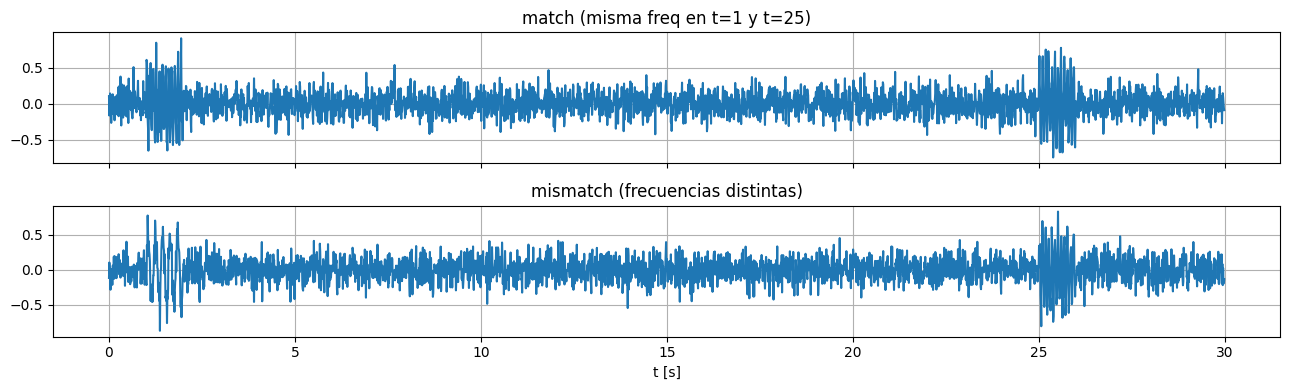

In [ ]:
FS_LC = 100; DUR_LC = 30.0; T_LC = int(DUR_LC * FS_LC)

def make_long_context(label, rng):
    t = np.arange(T_LC) / FS_LC
    sig = 0.15 * rng.standard_normal(T_LC).astype(np.float32)
    f1 = rng.choice([5, 12])
    sig[(t >= 1) & (t < 2)] += 0.5 * np.sin(2*np.pi*f1*t[(t >= 1) & (t < 2)])
    f2 = f1 if label == 0 else (12 if f1 == 5 else 5)
    sig[(t >= 25) & (t < 26)] += 0.5 * np.sin(2*np.pi*f2*t[(t >= 25) & (t < 26)])
    return sig.astype(np.float32)

rng = np.random.default_rng(11); n_per = 400
X_lc = np.stack([make_long_context(c, rng) for c in [0]*n_per + [1]*n_per])
y_lc = np.array([0]*n_per + [1]*n_per, dtype=np.int64)
idx = rng.permutation(len(X_lc)); X_lc, y_lc = X_lc[idx], y_lc[idx]
split = int(0.8*len(X_lc))
X_tr_lc, X_va_lc = X_lc[:split], X_lc[split:]
y_tr_lc, y_va_lc = y_lc[:split], y_lc[split:]

fig, axes = plt.subplots(2, 1, figsize=(13, 4), sharex=True)
axes[0].plot(np.arange(T_LC)/FS_LC, X_lc[y_lc == 0][0]); axes[0].set_title('match (misma freq en t=1 y t=25)')
axes[1].plot(np.arange(T_LC)/FS_LC, X_lc[y_lc == 1][0]); axes[1].set_title('mismatch (frecuencias distintas)')
axes[-1].set_xlabel('t [s]')
plt.tight_layout(); plt.show()

### Demo · una CNN no puede resolver esta tarea

Definimos una CNN razonable (3 conv layers con stride=2) y la entrenamos. Su campo receptivo no llega a abarcar los 30 s — queda en *chance level*.

In [ ]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, 7, stride=2, padding=3), nn.ReLU(),
            nn.Conv1d(16, 32, 5, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(32, 32, 5, stride=2, padding=2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(32, 2))
    def forward(self, x): return self.net(x)

def train_clf(model, X_tr, y_tr, X_va, y_va, epochs=10, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr); crit = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(torch.from_numpy(X_tr).float(), torch.from_numpy(y_tr)),
                        batch_size=32, shuffle=True)
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            loss = crit(model(xb.to(device).unsqueeze(1)), yb.to(device))
            opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(torch.from_numpy(X_va).float().to(device).unsqueeze(1)).argmax(1).cpu().numpy()
    return (pred == y_va).mean()

torch.manual_seed(0)
acc_cnn = train_clf(SmallCNN().to(device), X_tr_lc, y_tr_lc, X_va_lc, y_va_lc)
print(f'SmallCNN val_acc = {acc_cnn:.3f}  (chance = 0.50, CNN limitada por campo receptivo)')

SmallCNN val_acc = 0.525  (chance = 0.50, CNN limitada por campo receptivo)


### Ejercicio 3.1 — implementar y entrenar un mini-Transformer 1D (slide 33)

Implementá un Transformer simple que pueda resolver la tarea. La ventaja sobre la CNN es que **self-attention conecta cualquier par de instantes en una sola capa** — sin importar la distancia.

**Arquitectura:**

```
1. Patch embedding
   Conv1D(in=1, out=64, kernel_size=50, stride=50)   # cada patch = 0.5 s
   transpose para quedar [B, N_patches=60, dim=64]

2. Positional embedding (parámetro aprendido)
   nn.Parameter de shape [1, N_patches=60, dim=64], inicializado random pequeño
   Se suma a la salida del patch embedding

3. Bloque de atención (con conexión residual)
   LayerNorm  →  MultiheadAttention(dim=64, num_heads=4, batch_first=True)
   suma residual con la entrada del bloque

4. Bloque feed-forward (con conexión residual)
   LayerNorm  →  Linear(64 → 128)  →  GELU  →  Linear(128 → 64)
   suma residual

5. Clasificador
   promedio sobre patches (mean dim=1)  →  Linear(64 → 2)
```

**Entrenamiento:** 10 epochs, Adam (lr=3e-4), `CrossEntropyLoss`.

Después de entrenar, comparé el `val_acc` con `acc_cnn`. El Transformer debería resolver la tarea (~1.0), mientras que la CNN se queda en chance.

In [ ]:
# Tu código acá
class MiniTransformer(nn.Module):
    def __init__(self, seq_len=3000, patch_size=50, embed_dim=64, n_heads=4, n_classes=2):
        super().__init__()
        n_patches = seq_len // patch_size


        self.patch_embed = nn.Conv1d(1, embed_dim, kernel_size=patch_size, stride=patch_size)


        self.pos_embed = nn.Parameter(torch.randn(1, n_patches, embed_dim) * 0.02)


        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, n_heads, batch_first=True)


        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Linear(embed_dim * 2, embed_dim)
        )

        self.head = nn.Linear(embed_dim, n_classes)

    def forward(self, x):

        x = x.unsqueeze(1)


        x = self.patch_embed(x).transpose(1, 2)


        x = x + self.pos_embed


        attn_out, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x))
        x = x + attn_out


        x = x + self.ff(self.norm2(x))


        return self.head(x.mean(dim=1))



X_tr_lc_t = torch.from_numpy(X_tr_lc).float()
X_va_lc_t = torch.from_numpy(X_va_lc).float()
y_tr_lc_t = torch.from_numpy(y_tr_lc)

loader_lc = DataLoader(TensorDataset(X_tr_lc_t, y_tr_lc_t), batch_size=32, shuffle=True)

model_tr = MiniTransformer().to(device)
opt_tr = torch.optim.Adam(model_tr.parameters(), lr=3e-4)
crit_tr = nn.CrossEntropyLoss()

for epoch in range(10):
    model_tr.train()
    for xb, yb in loader_lc:
        loss = crit_tr(model_tr(xb.to(device)), yb.to(device))
        opt_tr.zero_grad(); loss.backward(); opt_tr.step()

model_tr.eval()
with torch.no_grad():
    pred_tr = model_tr(X_va_lc_t.to(device)).argmax(1).cpu().numpy()

val_acc_tr = (pred_tr == y_va_lc).mean()
print(f'SmallCNN  val_acc = {acc_cnn:.3f}')
print(f'Transformer val_acc = {val_acc_tr:.3f}')

SmallCNN  val_acc = 0.525
Transformer val_acc = 0.431


### Preguntas conceptuales — mini-Transformer (Ej 3.1)

Justificá brevemente cada decisión de la arquitectura. Una o dos oraciones por pregunta.

1. El **patch embedding** es una `Conv1D(kernel=50, stride=50)`. ¿Para qué partir la señal en patches? ¿Qué pasaría si pusiéramos todo el tensor directamente en la atención?
2. ¿Cuántos segundos cubre cada patch (a `fs=100 Hz`) y cuántos patches totales hay en una ventana de 30 s?
3. ¿Para qué hace falta el **positional embedding**? ¿Qué pasaría sin él en una tarea como esta (match/mismatch)?
4. En `MultiheadAttention(dim=64, num_heads=4)`: ¿qué representa cada **cabeza** y por qué se usan varias en paralelo?
5. ¿Por qué hay **conexiones residuales** (`e = e + attn_out`)? ¿Qué problema previenen?
6. ¿Para qué sirve el **bloque feed-forward** después de la atención si ya hicimos atención? ¿Por qué la dimensión interna es `2 × EMBED`?
7. ¿Por qué `LayerNorm` y no `BatchNorm` (como sí usamos en EEGNet)?
8. ¿Por qué hacemos `e.mean(dim=1)` al final antes del clasificador?

1. Si metiéramos los 3000 samples directamente en la atención, tendríamos 3000 tokens y la atención es O(T²) en memoria — con 3000 tokens eso explota. Los patches reducen la secuencia a 60 tokens manejables.

2. Cada patch cubre 50/100 = 0.5 segundos, y hay 60 patches en total (3000/50). Medio segundo alcanza para capturar un evento de frecuencia como los spikes de 5 o 12 Hz.

3. Sin positional embedding la atención no sabe si el patch 1 viene antes o después del patch 60 — trata todo como una bolsa de tokens sin orden. Para esta tarea importa cuándo ocurre cada frecuencia, entonces necesita saber la posición.

4. Cada cabeza aprende a prestar atención a distintas relaciones entre patches. Una cabeza puede enfocarse en comparar el patch del segundo 1 con el del segundo 25, otra puede fijarse en otra cosa. Juntas capturan más tipos de dependencias.

5. Las conexiones residuales suman la entrada a la salida de cada bloque, entonces si un bloque no aprende nada útil la señal pasa igual. Previenen que el gradiente desaparezca al entrenar redes profundas.

6. La atención decide qué información es relevante y de dónde viene, pero no transforma esa información. El feed-forward aplica una transformación no lineal a cada token, dándole más capacidad expresiva al modelo. La dimensión interna 2× es una convención que aumenta capacidad sin explotar en parámetros.

7. LayerNorm normaliza sobre la dimensión de features de cada token por separado, sin depender del batch. BatchNorm normaliza sobre el batch, lo cual en secuencias de largo variable o batches chicos se vuelve inestable.

8. Promediando sobre los 60 patches obtenemos un vector fijo de tamaño 64 que resume toda la secuencia, y ese vector lo clasificamos. Es la forma más simple de colapsar la dimensión temporal sin perder demasiado.

## Cierre — takeaways de la clase

1. **Una señal 1D = lista de números + `fs`.** ECG, EEG y PPG son instancias del mismo concepto.
2. **El filtro deslizante es el throughline.** Pan-Tompkins → Conv1D → self-attention — lo que cambia es **cuántos parámetros**    y **cuánto contexto** ve cada operación.
3. **AI extiende al clásico, no lo reemplaza.** Pan-Tompkins de 1985 sigue siendo baseline en producción.
4. **Dimensionalidad escala el problema.** ECG (1D) → PPG (1D + movimiento) → EEG (2D = canales × tiempo). El framework es el mismo;    la arquitectura se adapta.
5. **Las CNNs tienen campo receptivo finito.** Cuando la tarea requiere contexto largo, hay que ir a Transformers.